In [13]:
import numpy as np
from matplotlib import pyplot as plt
import cyipopt

np.set_printoptions(precision=3, suppress=True)



In [14]:
def serialize(A_hat, b_hat):
    try:
        with open("D:/data/calibration.txt", 'w') as f:
            for row in A_hat:
                f.write(' '.join(map(str, row)) + '\n')
            f.write(' '.join(map(str, b_hat)) + '\n')
    except:
        pass
    finally:
        for row in A_hat:
            print(', '.join(map(str, row)) + ',' )
        print(', '.join(map(str, b_hat)) )



In [15]:
from analysis import process_file_to_raw_data
from ellipsoid_fit import plot_ellipsoid

def normalize(vec):
    if len(vec.shape) == 1:
        return vec / np.linalg.norm(vec)
    return vec / np.linalg.norm(vec, axis=1, keepdims=True)

def load_data(filename="magacc_readings_8.txt", atol=0.4):
    data = process_file_to_raw_data(filename)
    mag = data[:,:3]
    acc = data[:,3:]

    norm = np.linalg.norm(acc, 2, axis=1)
    idcs = np.isclose(norm, 9.8, atol=atol)

    mag = mag[idcs]
    acc = acc[idcs]

    mag = np.array(mag)
    acc = np.array(acc)
    return mag, acc



In [16]:

# Symmetric 4x4 parameter ordering:
# (00, 11, 22, 33, 01, 02, 03, 12, 13, 23)
Q_PAIRS = (
    (0, 0), (1, 1), (2, 2), (3, 3),
    (0, 1), (0, 2), (0, 3),
    (1, 2), (1, 3), (2, 3),
)


def q_to_matrix(q):
    Q = np.zeros((4, 4))
    for value, (i, j) in zip(q, Q_PAIRS):
        Q[i, j] = Q[j, i] = value
    return Q


def matrix_to_q(Q):
    return np.array([Q[i, j] for i, j in Q_PAIRS])


def quadratic_features(x):
    """phi(x)^T q = x^T Q x."""
    return np.array([
        x[0] ** 2,
        x[1] ** 2,
        x[2] ** 2,
        x[3] ** 2,
        2 * x[0] * x[1],
        2 * x[0] * x[2],
        2 * x[0] * x[3],
        2 * x[1] * x[2],
        2 * x[1] * x[3],
        2 * x[2] * x[3],
    ])


class StreamingExactCalibration:
    """
    Decision variables:
        W: 3x4 affine calibration matrix
        Q: symmetric 4x4 matrix

    Objective:
        alpha/2 * mean[(a^T W x - T)^2]
      + beta /2 * mean[(x^T Q x - 1)^2]

    Exact constraints:
        Q = W^T W
    """

    def __init__(self, target_dot, alpha=1.0, beta=1.0):
        self.T = float(target_dot)
        self.alpha = float(alpha)
        self.beta = float(beta)

        self.Ha = np.zeros((12, 12))
        self.ga = np.zeros(12)

        self.Hn = np.zeros((10, 10))
        self.gn = np.zeros(10)

        self.n = 0

        # Lower-triangular indices required by Ipopt.
        self.hess_rows, self.hess_cols = np.tril_indices(22)

        # Constant Hessian of each equality constraint.
        self.constraint_hessians = self._make_constraint_hessians()

    def update(self, mag_raw, acc, weight=1.0, W0=None):
        mag_raw = np.asarray(mag_raw, dtype=float)
        acc = np.asarray(acc, dtype=float)

        acc = acc / np.linalg.norm(acc)
        x = np.r_[mag_raw, 1.0]

        # Compute scale factor based on previous solution
        scale = 1.0 if W0 is None else np.linalg.norm(W0 @ x)

        # a^T W x = z^T vec_row(W)
        z = np.kron(acc, x)

        # x^T Q x = phi^T q
        phi = quadratic_features(x)

        self.Ha += weight * np.outer(z, z) / scale**2
        self.ga += weight * self.T * z 

        self.Hn += weight * np.outer(phi, phi)
        self.gn += weight * phi

        self.n += 1
        mag_raw = np.asarray(mag_raw, dtype=float)
        acc = np.asarray(acc, dtype=float)

        acc = acc / np.linalg.norm(acc)
        x = np.r_[mag_raw, 1.0]

        # a^T W x = z^T vec_row(W)
        z = np.kron(acc, x)

        # x^T Q x = phi^T q
        phi = quadratic_features(x)

        self.Ha += weight * np.outer(z, z)
        self.ga += weight * self.T * z

        self.Hn += weight * np.outer(phi, phi)
        self.gn += weight * phi

        self.n += 1

    def _split(self, theta):
        W = theta[:12].reshape(3, 4)
        q = theta[12:]
        return W, q

    def objective(self, theta):
        w = theta[:12]
        q = theta[12:]
        scale = 1.0 / max(self.n, 1)

        return 0.5 * scale * (
            self.alpha * (w @ self.Ha @ w - 2 * self.ga @ w)
            + self.beta * (q @ self.Hn @ q - 2 * self.gn @ q)
        )

    def gradient(self, theta):
        w = theta[:12]
        q = theta[12:]
        scale = 1.0 / max(self.n, 1)

        return scale * np.r_[
            self.alpha * (self.Ha @ w - self.ga),
            self.beta * (self.Hn @ q - self.gn),
        ]

    def constraints(self, theta):
        W, q = self._split(theta)
        gram = W.T @ W

        return np.array([
            q[k] - gram[i, j]
            for k, (i, j) in enumerate(Q_PAIRS)
        ])

    def jacobian(self, theta):
        W, _ = self._split(theta)

        # Dense 10x22 Jacobian.
        J = np.zeros((10, 22))

        for k, (p, q) in enumerate(Q_PAIRS):
            # Derivative with respect to q_k.
            J[k, 12 + k] = 1.0

            # Derivative of -(W^T W)_{pq}.
            for row in range(3):
                wp = 4 * row + p
                wq = 4 * row + q

                if p == q:
                    J[k, wp] = -2.0 * W[row, p]
                else:
                    J[k, wp] = -W[row, q]
                    J[k, wq] = -W[row, p]

        return J.ravel(order="C")

    def _make_constraint_hessians(self):
        """
        Hessians of:
            c_pq = Q_pq - sum_r W[r,p] W[r,q].

        Only the W-W blocks are nonzero.
        """
        hessians = np.zeros((10, 22, 22))

        for k, (p, q) in enumerate(Q_PAIRS):
            for row in range(3):
                wp = 4 * row + p
                wq = 4 * row + q

                if p == q:
                    hessians[k, wp, wp] = -2.0
                else:
                    hessians[k, wp, wq] = -1.0
                    hessians[k, wq, wp] = -1.0

        return hessians

    def hessianstructure(self):
        return self.hess_rows, self.hess_cols

    def hessian(self, theta, lagrange, obj_factor):
        scale = 1.0 / max(self.n, 1)

        H = np.zeros((22, 22))

        # Objective Hessian.
        H[:12, :12] = obj_factor * scale * self.alpha * self.Ha
        H[12:, 12:] = obj_factor * scale * self.beta * self.Hn

        # Equality-constraint Hessians.
        H += np.tensordot(
            lagrange,
            self.constraint_hessians,
            axes=(0, 0),
        )

        return H[self.hess_rows, self.hess_cols]

    def solve(self, W0=None):
        if self.n == 0:
            raise ValueError("No samples have been accumulated.")

        if W0 is None:
            # Alignment-only least-squares initialization.
            ridge = 1e-8 * np.eye(12)
            w0 = np.linalg.solve(self.Ha + ridge, self.ga)
            W0 = w0.reshape(3, 4)

        # Start exactly feasible: Q0 = W0^T W0.
        Q0 = W0.T @ W0
        theta0 = np.r_[W0.ravel(), matrix_to_q(Q0)]

        nlp = cyipopt.Problem(
            n=22,
            m=10,
            problem_obj=self,
            lb=np.full(22, -np.inf),
            ub=np.full(22, np.inf),
            cl=np.zeros(10),
            cu=np.zeros(10),
        )

        nlp.add_option("tol", 1e-9)
        nlp.add_option("constr_viol_tol", 1e-10)
        nlp.add_option("max_iter", 500)
        nlp.add_option("mu_strategy", "adaptive")
        nlp.add_option("hessian_approximation", "exact")
        nlp.add_option("print_level", 0)

        theta, info = nlp.solve(theta0)

        W, q = self._split(theta)
        Q = q_to_matrix(q)

        return W, Q, info
    

In [17]:
def grade(a, b):
    z = np.array([i@j for i,j in zip(a,b)])
    return np.mean(z), np.std(z)


In [ ]:
mag_raw, acc = load_data("data/magacc_readings_14.txt", atol=0.3)
T = 0.907

cal = StreamingExactCalibration(target_dot=T, alpha=1.0, beta=1.0)
for m_raw, a in zip(mag_raw, acc):
    cal.update(m_raw, a)
W_hat, Q_hat, info = cal.solve()
M_aug = np.column_stack([mag_raw, np.ones(len(mag_raw))])
M = M_aug @ W_hat.T
Mn = M / np.linalg.norm(M, axis=1, keepdims=True)
A = acc / np.linalg.norm(acc, axis=1, keepdims=True)
print(f"{grade(M,M)[0].item():.03f}  {grade(A,M)[0].item():.03f}  {grade(A,Mn)[0].item():.03f}")

for i in range(2):
    cal = StreamingExactCalibration(target_dot=T, alpha=1.0, beta=10.0)
    for m_raw, a in zip(mag_raw, acc):
        cal.update(m_raw, a, W0=W_hat)
    W_hat, Q_hat, info = cal.solve(W0=W_hat)
    M_aug = np.column_stack([mag_raw, np.ones(len(mag_raw))])
    M = M_aug @ W_hat.T
    Mn = M / np.linalg.norm(M, axis=1, keepdims=True)
    A = acc / np.linalg.norm(acc, axis=1, keepdims=True)
    print(f"{grade(M,M)[0].item():.03f}  {grade(A,M)[0].item():.03f}  {grade(A,Mn)[0].item():.03f}")
    
A_hat = W_hat[:, :3]
b_hat = W_hat[:, 3]


0.993  0.918  0.922
1.000  0.902  0.902
1.000  0.905  0.905
1.000  0.905  0.905
1.000  0.905  0.905
1.000  0.905  0.905


In [19]:
W_hat

array([[ 0.005, -0.   , -0.001,  0.237],
       [-0.001, -0.006,  0.002,  0.448],
       [-0.002,  0.004, -0.003,  0.813]])

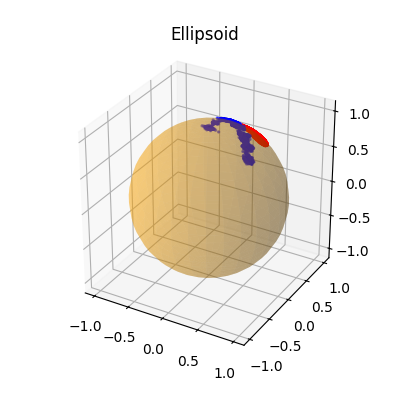

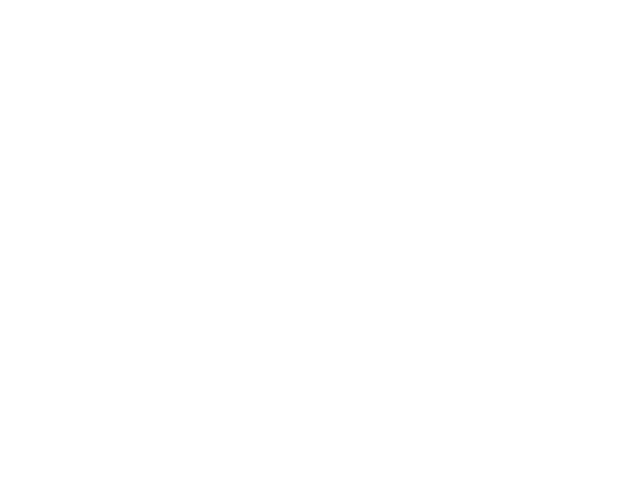

In [20]:
%matplotlib widget
from ellipsoid_fit import plot_ellipsoid
plt.clf()
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')

M = (A_hat @ mag_raw.T).T + b_hat
A = acc / np.linalg.norm(acc, axis=1, keepdims=True)
plot_ellipsoid(ax, center=np.zeros(3), R=np.eye(3), radii=np.ones(3))

ax.scatter(*M.T, c='red', marker='o', s=2, alpha=0.5, label='Mag')
ax.scatter(*A.T, c='blue', marker='o', s=2, alpha=0.5, label='Accel')

plt.show()

In [21]:
%matplotlib inline

In [ ]:
M = (A_hat @ mag_raw.T).T + b_hat
Mn = M / np.linalg.norm(M, axis=1, keepdims=True)
A = acc / np.linalg.norm(acc, axis=1, keepdims=True)

norms = np.array([m@m for m in M])
dots = np.array([m@a for m,a in zip(M,A)])
normdots = np.array([m@a for m,a in zip(Mn,A)])

plt.clf()
plt.figure(figsize=(5,2))
plt.hist(norms, 30)
plt.title("vector norm")
plt.xlim(.75,1.25)
plt.gca().axvline(x=1, c='r')
plt.show()

plt.figure(figsize=(5,2))
plt.hist(dots, 30, label="unnormalized")
plt.hist(normdots, 30, alpha=0.5, color="C1", label="normalized")
plt.title("dot products")
plt.gca().axvline(x=T, c='r')
plt.legend(loc=0)
plt.show()

<Figure size 2304x1728 with 0 Axes>

<Figure size 1440x1440 with 0 Axes>

In [ ]:
serialize(A_hat, b_hat)

-0.02176926417628269, 0.0009893921107697718, 0.0014285577453895127,
-0.0009474406267853217, -0.02132069019514194, 0.0004587401055485154,
-0.00042830491915379177, 0.0009044329326522049, -0.01780446399709313,
0.26246213955089187, -0.2778302698796419, 0.5615001190394754
